#  Analiza Explainability: LIME + SHAP

## Logika:
- Trenujemy model RandomForest na fingerprintach interakcji (ProLIF)
- SHAP: globalne znaczenie cech (średni wpływ na wszystkie predykcje)
- LIME: lokalne wyjaśnienia (dlaczego TEN konkretny związek jest aktywny/nieaktywny)
- Porównujemy: czy SHAP i LIME się zgadzają?

In [19]:
# Importy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import shap
import lime
import lime.lime_tabular

# Ustawienia wykresów
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('Biblioteki załadowane')

Biblioteki załadowane


## 1. Wczytanie danych

Używamy fingerprintów interakcji z numeracją Ballesteros-Weinstein (BW)
- Kolumny: `[residue_BW]_[interaction_type]` np. `3x32_Cationic`
- Wartości: 0/1 (brak/obecność interakcji)

In [20]:
# Wczytaj dane
df = pd.read_csv('explainable-fingerprints/Fingerprints/DRD2/ifp_DRD2_BW.csv')

print(f'Dane wczytane: {df.shape[0]} związków, {df.shape[1]} kolumn')
print(f'\nRozkład klas:')
print(df['label'].value_counts())
print(f'\nZbalansowane: {df["label"].value_counts()[0]} nieaktywne, {df["label"].value_counts()[1]} aktywne')

# Podział na X i y
X = df.drop(columns=['molecule_name', 'label'])
y = df['label']
feature_names = X.columns.tolist()
molecule_names = df['molecule_name'].values

print(f'\nLiczba cech: {len(feature_names)}')
print(f'\nPrzykładowe cechy:')
for i, feat in enumerate(feature_names[:10]):
    print(f'  {i+1}. {feat}')

Dane wczytane: 1583 związków, 118 kolumn

Rozkład klas:
label
0    798
1    785
Name: count, dtype: int64

Zbalansowane: 798 nieaktywne, 785 aktywne

Liczba cech: 116

Przykładowe cechy:
  1. 1x35_Hydrophobic
  2. 2x60_HBDonor
  3. 2x60_Hydrophobic
  4. 2x60_VdWContact
  5. 2x60_XBDonor
  6. 2x63_HBDonor
  7. 2x63_Hydrophobic
  8. 2x63_VdWContact
  9. 2x64_Cationic
  10. 2x64_HBDonor


## 2. Trening modelu
od zosi

In [21]:
# Podział train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_idx = X_train.index
test_idx = X_test.index
test_molecule_names = molecule_names[test_idx]

print(f'Train set: {X_train.shape[0]} związków')
print(f'Test set: {X_test.shape[0]} związków')

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    random_state=42,
    n_jobs=-1
)

print('\nTrenowanie modelu...')
model.fit(X_train, y_train)

# Ewaluacja
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print(f'\nModel wytrenowany!')
print(f'\nWyniki na test set:')
print(f'  AUC-ROC: {auc:.3f}')
print(f'\n{classification_report(y_test, y_pred, target_names=["Nieaktywny", "Aktywny"])}')

Train set: 1266 związków
Test set: 317 związków

Trenowanie modelu...

Model wytrenowany!

Wyniki na test set:
  AUC-ROC: 0.722

              precision    recall  f1-score   support

  Nieaktywny       0.69      0.67      0.68       160
     Aktywny       0.67      0.69      0.68       157

    accuracy                           0.68       317
   macro avg       0.68      0.68      0.68       317
weighted avg       0.68      0.68      0.68       317



## 3. SHAP - Globalne znaczenie cech

- Każdej cesze przypisuje "sprawiedliwą" wartość jej wkładu w predykcję
- **Wartość SHAP** = o ile zmienia się predykcja gdy dodamy/usuniemy tę cechę

**Interpretacja:**
- Dodatnia wartość SHAP → cecha zwiększa prawdopodobieństwo klasy 1 (aktywny)
- Ujemna wartość SHAP → cecha zmniejsza prawdopodobieństwo klasy 1

In [22]:
# Oblicz SHAP values
print('Obliczanie SHAP values...')
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# TreeExplainer zwraca wartości dla obu klas [klasa 0, klasa 1]
# Nas interesuje klasa 1 (aktywne związki)
shap_values_class1 = shap_values.values[:, :, 1]

print(f'SHAP values obliczone!')
print(f'  Shape: {shap_values_class1.shape} (związki x cechy)')
print(f'  Zakres wartości: [{shap_values_class1.min():.3f}, {shap_values_class1.max():.3f}]')

Obliczanie SHAP values...
SHAP values obliczone!
  Shape: (317, 116) (związki x cechy)
  Zakres wartości: [-0.084, 0.114]


### 3.1 SHAP Summary Plot - Globalny przegląd

**Jak czytać:**
- Oś Y: cechy posortowane według ważności
- Oś X: wartość SHAP (wpływ na predykcję)
- Kolor punktu: wartość cechy (czerwony = 1 = interakcja obecna, niebieski = 0 = brak)
- Każdy punkt = jeden związek

**Przykład interpretacji:**
- Jeśli czerwone punkty są po prawej stronie → gdy interakcja jest obecna (1), model przewiduje aktywny
- Jeśli niebieskie punkty są po lewej → gdy interakcji brak (0), model przewiduje nieaktywny

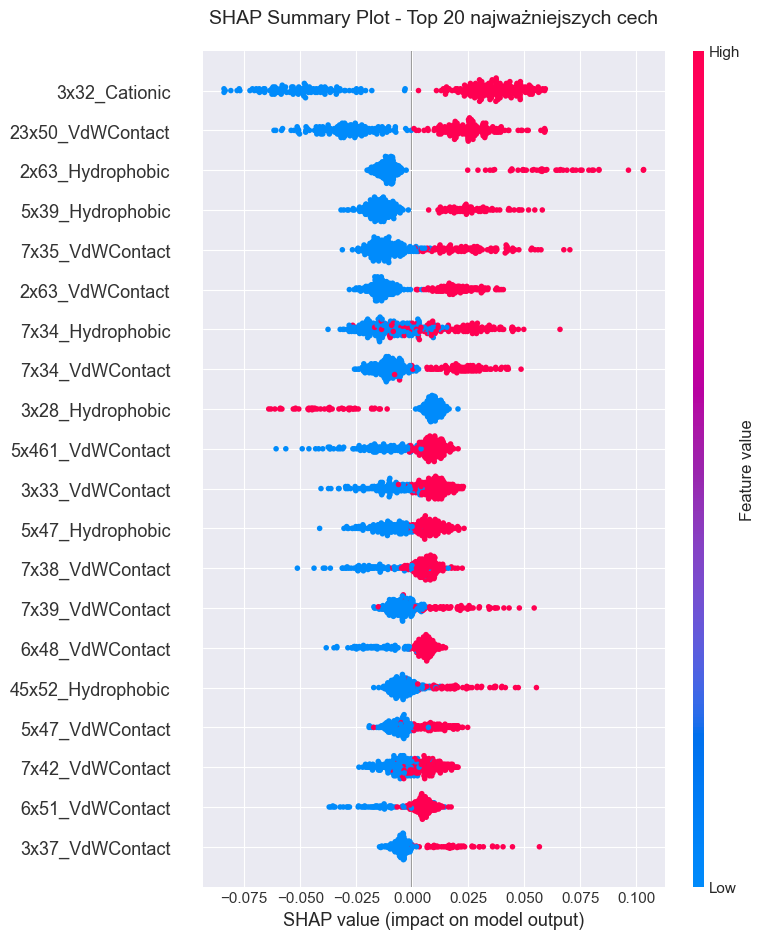


Interpretacja:
  - Czerwone punkty po prawej = obecność interakcji zwiększa aktywność
  - Niebieskie punkty po lewej = brak interakcji zmniejsza aktywność


In [23]:
# Summary plot - top 20 cech
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_class1,
    X_test,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot - Top 20 najważniejszych cech', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print('\nInterpretacja:')
print('  - Czerwone punkty po prawej = obecność interakcji zwiększa aktywność')
print('  - Niebieskie punkty po lewej = brak interakcji zmniejsza aktywność')

### 3.2 SHAP Bar Plot - Średnia ważność cech

- zawiera średnia absolutna wartość SHAP dla każdej cechy
- Im wyższa wartość = tym większy wpływ na model (niezależnie od kierunku)

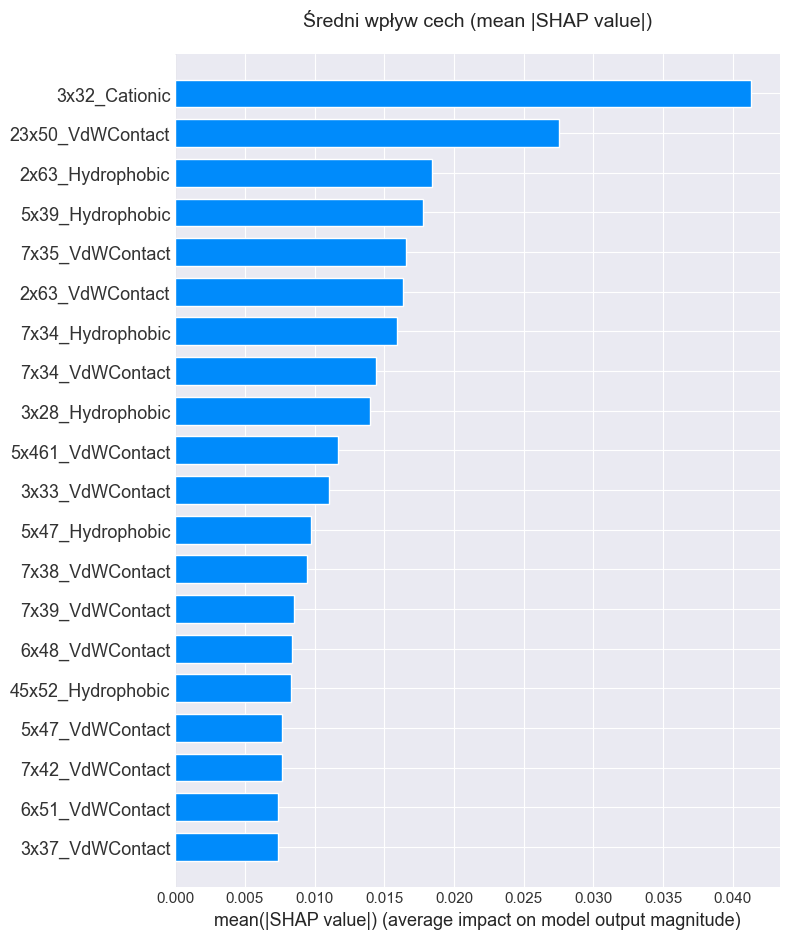


Top 10 najważniejszych cech według SHAP:
         feature  mean_abs_shap
   3x32_Cationic       0.041320
23x50_VdWContact       0.027534
2x63_Hydrophobic       0.018409
5x39_Hydrophobic       0.017767
 7x35_VdWContact       0.016520
 2x63_VdWContact       0.016304
7x34_Hydrophobic       0.015893
 7x34_VdWContact       0.014435
3x28_Hydrophobic       0.013938
5x461_VdWContact       0.011681


In [24]:
# Bar plot - średnia ważność
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_class1,
    X_test,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Średni wpływ cech (mean |SHAP value|)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Zapisanie rankingu cech
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print('\nTop 10 najważniejszych cech według SHAP:')
print(shap_importance_df.head(10).to_string(index=False))

## 4. Wybór przykładowych związków do analizy LIME
zeby sprawdzić jak model podjął decyzję w każdym z tych przypadków

1. **2 prawdziwie pozytywne (TP)** - aktywne, model przewidział aktywne
2. **2 prawdziwie negatywne (TN)** - nieaktywne, model przewidział nieaktywne
3. **1 fałszywie pozytywny (FP)** - nieaktywny, model pomylił się
4. **1 fałszywie negatywny (FN)** - aktywny, model pomylił się
5. **1 borderline** - prawdopodobieństwo ~0.5 (model niepewny)


In [25]:
#  przykłady
y_test_array = y_test.values
y_pred_array = y_pred
y_prob_array = y_prob

# True Positives (aktywne, dobrze sklasyfikowane)
tp_mask = (y_test_array == 1) & (y_pred_array == 1)
tp_indices = np.where(tp_mask)[0]
# Wybór 2: jeden z wysokim confidence, jeden średnim
tp_probs = y_prob_array[tp_indices]
tp_high = tp_indices[np.argmax(tp_probs)]  # najbardziej pewny
tp_mid_idx = np.argsort(np.abs(tp_probs - 0.75))[0]  # najbliżej 0.75
tp_mid = tp_indices[tp_mid_idx]

# True Negatives (nieaktywne, dobrze sklasyfikowane)
tn_mask = (y_test_array == 0) & (y_pred_array == 0)
tn_indices = np.where(tn_mask)[0]
tn_probs = y_prob_array[tn_indices]
tn_high = tn_indices[np.argmin(tn_probs)]  # najbardziej pewny (najniższe prob)
tn_mid_idx = np.argsort(np.abs(tn_probs - 0.25))[0]  # najbliżej 0.25
tn_mid = tn_indices[tn_mid_idx]

# False Positive (nieaktywny, błędnie jako aktywny)
fp_mask = (y_test_array == 0) & (y_pred_array == 1)
fp_indices = np.where(fp_mask)[0]
if len(fp_indices) > 0:
    fp_example = fp_indices[np.argmax(y_prob_array[fp_indices])]  # najbardziej pewny błąd
else:
    fp_example = None

# False Negative (aktywny, błędnie jako nieaktywny)
fn_mask = (y_test_array == 1) & (y_pred_array == 0)
fn_indices = np.where(fn_mask)[0]
if len(fn_indices) > 0:
    fn_example = fn_indices[np.argmin(y_prob_array[fn_indices])]  # najbardziej pewny błąd
else:
    fn_example = None

# Borderline (najbliżej 0.5)
borderline_idx = np.argmin(np.abs(y_prob_array - 0.5))

# Zbierz przykłady
examples = [
    ('TP_high_conf', tp_high),
    ('TP_mid_conf', tp_mid),
    ('TN_high_conf', tn_high),
    ('TN_mid_conf', tn_mid),
    ('Borderline', borderline_idx)
]

if fp_example is not None:
    examples.append(('FP', fp_example))
if fn_example is not None:
    examples.append(('FN', fn_example))

# Wyświetl wybrane przykłady
print('\nWybrane przykłady do analizy LIME:\n')
print(f'{"Typ":<15} {"Molekuła":<20} {"Prawdziwa":<12} {"Predykcja":<12} {"Prawdop.":<10}')
print('-' * 70)

for ex_type, ex_idx in examples:
    mol_name = test_molecule_names[ex_idx]
    true_label = 'Aktywny' if y_test_array[ex_idx] == 1 else 'Nieaktywny'
    pred_label = 'Aktywny' if y_pred_array[ex_idx] == 1 else 'Nieaktywny'
    prob = y_prob_array[ex_idx]
    print(f'{ex_type:<15} {mol_name:<20} {true_label:<12} {pred_label:<12} {prob:.3f}')


Wybrane przykłady do analizy LIME:

Typ             Molekuła             Prawdziwa    Predykcja    Prawdop.  
----------------------------------------------------------------------
TP_high_conf    CHEMBL244989         Aktywny      Aktywny      0.818
TP_mid_conf     CHEMBL1774543        Aktywny      Aktywny      0.757
TN_high_conf    CHEMBL4446215        Nieaktywny   Nieaktywny   0.057
TN_mid_conf     CHEMBL4076796        Nieaktywny   Nieaktywny   0.247
Borderline      CHEMBL5790341        Aktywny      Aktywny      0.500
FP              CHEMBL3289985        Nieaktywny   Aktywny      0.774
FN              CHEMBL64508          Aktywny      Nieaktywny   0.151


## 5. LIME - Lokalne wyjaśnienia

**Co to jest LIME?**
- Local Interpretable Model-agnostic Explanations
- Wyjaśnia JEDNĄ konkretną predykcję
- Perturbuje (zmienia) wartości cech i patrzy jak zmienia się predykcja
- Trenuje prosty model liniowy lokalnie wokół tego przykładu

**Różnica LIME vs SHAP:**
- **SHAP**: globalne, teoretycznie uzasadnione, pokazuje średni wpływ na wszystkie przykłady
- **LIME**: lokalne, aproksymacja, pokazuje wpływ dla TEGO konkretnego przykładu

**Kiedy się różnią:**
- Gdy interakcje między cechami są silne
- Gdy jedna cecha jest ważna globalnie, ale nie dla tego przykładu

In [26]:
# Inicjalizuj LIME explainer
print('Inicjalizacja LIME explainer...')

# LIME wymaga nazw klas jako strings
class_names = ['Nieaktywny', 'Aktywny']

# Tabular explainer dla danych tabelarycznych
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    discretize_continuous=False  # nasze cechy są już binarne
)

print('LIME explainer gotowy!')
print(f'  Training set size: {X_train.shape[0]}')
print(f'  Features: {len(feature_names)}')

Inicjalizacja LIME explainer...
LIME explainer gotowy!
  Training set size: 1266
  Features: 116


### 5.1 LIME wyjaśnienia dla wybranych przykładów

**Jak czytać wykres LIME:**
- Paski w prawo (pomarańczowe/niebieskie) = zwiększa prawdopodobieństwo tej klasy
- Paski w lewo = zmniejsza prawdopodobieństwo
- Wartość obok = faktyczna wartość cechy dla tego związku (0 lub 1)
- Im dłuższy pasek = tym większy wpływ tej cechy na TĘ predykcję

Analizujemy 7 typów przykładów, żeby zobaczyć jak model myśli w różnych sytuacjach:
TP (True Positive) - aktywny, dobrze przewidziany → jakie interakcje sprawiają że związek jest aktywny?
TN (True Negative) - nieaktywny, dobrze przewidziany → czego brakuje?
FP (False Positive) - nieaktywny ale model się pomylił → co go zmyliło?
FN (False Negative) - aktywny ale model go przegapił → czego model nie zauważył?
Borderline (~50% pewności) - model niepewny → dlaczego?


In [35]:
# Generuj LIME wyjaśnienia dla każdego przykładu
print('Generowanie LIME wyjaśnień...\n')

lime_results = {}

for ex_type, ex_idx in examples:
    print(f'\n{"="*70}')
    print(f'Analiza przykładu: {ex_type}')
    print(f'{"="*70}\n')
    
    instance = X_test.iloc[ex_idx].values
    true_label = y_test_array[ex_idx]
    pred_prob = y_prob_array[ex_idx]
    mol_name = test_molecule_names[ex_idx]
    
    #  LIME explanation
    # num_features = liczba cech do pokazania
    # num_samples = liczba perturbacji do wygenerowania (więcej = dokładniej ale wolniej)
    lime_exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=model.predict_proba,
        num_features=10,
        num_samples=5000
    )
    
    #  top cechy dla klasy 1 (aktywny)
    exp_list = lime_exp.as_list(label=1)
    
    # Sortowanie według wartości bezwzględnej
    exp_list = sorted(exp_list, key=lambda x: abs(x[1]), reverse=True)[:10]
    
    # Zapisz wyniki
    lime_results[ex_type] = {
        'idx': ex_idx,
        'mol_name': mol_name,
        'true_label': true_label,
        'pred_prob': pred_prob,
        'explanation': exp_list
    }
    
    print(f'\nTop 10 cech według LIME:')
    for i, (feat, val) in enumerate(exp_list, 1):
        direction = 'zwiększa' if val > 0 else 'zmniejsza'
        print(f'  {i:2d}. {feat:<40} {direction:12} ({val:+.4f})')



Generowanie LIME wyjaśnień...


Analiza przykładu: TP_high_conf


Top 10 cech według LIME:
   1. 3x32_Cationic                            zwiększa     (+0.0317)
   2. 2x63_Hydrophobic                         zwiększa     (+0.0210)
   3. 23x50_VdWContact                         zwiększa     (+0.0196)
   4. 5x39_Hydrophobic                         zwiększa     (+0.0166)
   5. 7x35_VdWContact                          zwiększa     (+0.0163)
   6. 2x63_VdWContact                          zwiększa     (+0.0142)
   7. 7x39_VdWContact                          zwiększa     (+0.0077)
   8. 2x64_VdWContact                          zwiększa     (+0.0062)
   9. 7x39_Hydrophobic                         zwiększa     (+0.0062)
  10. 2x64_Hydrophobic                         zwiększa     (+0.0050)

Analiza przykładu: TP_mid_conf



C:\Users\agata\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\agata\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Top 10 cech według LIME:
   1. 3x32_Cationic                            zwiększa     (+0.0308)
   2. 2x63_Hydrophobic                         zwiększa     (+0.0195)
   3. 23x50_VdWContact                         zwiększa     (+0.0191)
   4. 5x39_Hydrophobic                         zwiększa     (+0.0189)
   5. 7x35_VdWContact                          zwiększa     (+0.0144)
   6. 2x63_VdWContact                          zwiększa     (+0.0129)
   7. 7x34_VdWContact                          zwiększa     (+0.0112)
   8. 7x34_Hydrophobic                         zwiększa     (+0.0111)
   9. 5x47_Hydrophobic                         zwiększa     (+0.0098)
  10. 3x33_VdWContact                          zwiększa     (+0.0097)

Analiza przykładu: TN_high_conf


Top 10 cech według LIME:
   1. 3x32_Cationic                            zwiększa     (+0.0319)
   2. 23x50_VdWContact                         zwiększa     (+0.0179)
   3. 5x39_Hydrophobic                         zwiększa     (+0.0170)
   4

C:\Users\agata\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\agata\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Top 10 cech według LIME:
   1. 3x32_Cationic                            zwiększa     (+0.0316)
   2. 2x63_Hydrophobic                         zwiększa     (+0.0220)
   3. 23x50_VdWContact                         zwiększa     (+0.0172)
   4. 5x39_Hydrophobic                         zwiększa     (+0.0159)
   5. 2x63_VdWContact                          zwiększa     (+0.0135)
   6. 7x35_VdWContact                          zwiększa     (+0.0134)
   7. 7x34_VdWContact                          zwiększa     (+0.0119)
   8. 3x33_VdWContact                          zwiększa     (+0.0103)
   9. 5x461_VdWContact                         zwiększa     (+0.0086)
  10. 7x38_VdWContact                          zwiększa     (+0.0079)

Analiza przykładu: Borderline


Top 10 cech według LIME:
   1. 3x32_Cationic                            zwiększa     (+0.0311)
   2. 23x50_VdWContact                         zwiększa     (+0.0209)
   3. 5x39_Hydrophobic                         zwiększa     (+0.0163)
   4. 

C:\Users\agata\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\agata\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Top 10 cech według LIME:
   1. 3x32_Cationic                            zwiększa     (+0.0318)
   2. 2x63_Hydrophobic                         zwiększa     (+0.0212)
   3. 23x50_VdWContact                         zwiększa     (+0.0173)
   4. 5x39_Hydrophobic                         zwiększa     (+0.0153)
   5. 7x35_VdWContact                          zwiększa     (+0.0144)
   6. 2x63_VdWContact                          zwiększa     (+0.0142)
   7. 5x461_VdWContact                         zwiększa     (+0.0103)
   8. 3x33_VdWContact                          zwiększa     (+0.0101)
   9. 7x39_VdWContact                          zwiększa     (+0.0076)
  10. 2x60_VdWContact                          zwiększa     (+0.0045)

Analiza przykładu: FN


Top 10 cech według LIME:
   1. 3x32_Cationic                            zwiększa     (+0.0306)
   2. 23x50_VdWContact                         zwiększa     (+0.0189)
   3. 5x39_Hydrophobic                         zwiększa     (+0.0161)
   4. 7x35_VdW

C:\Users\agata\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


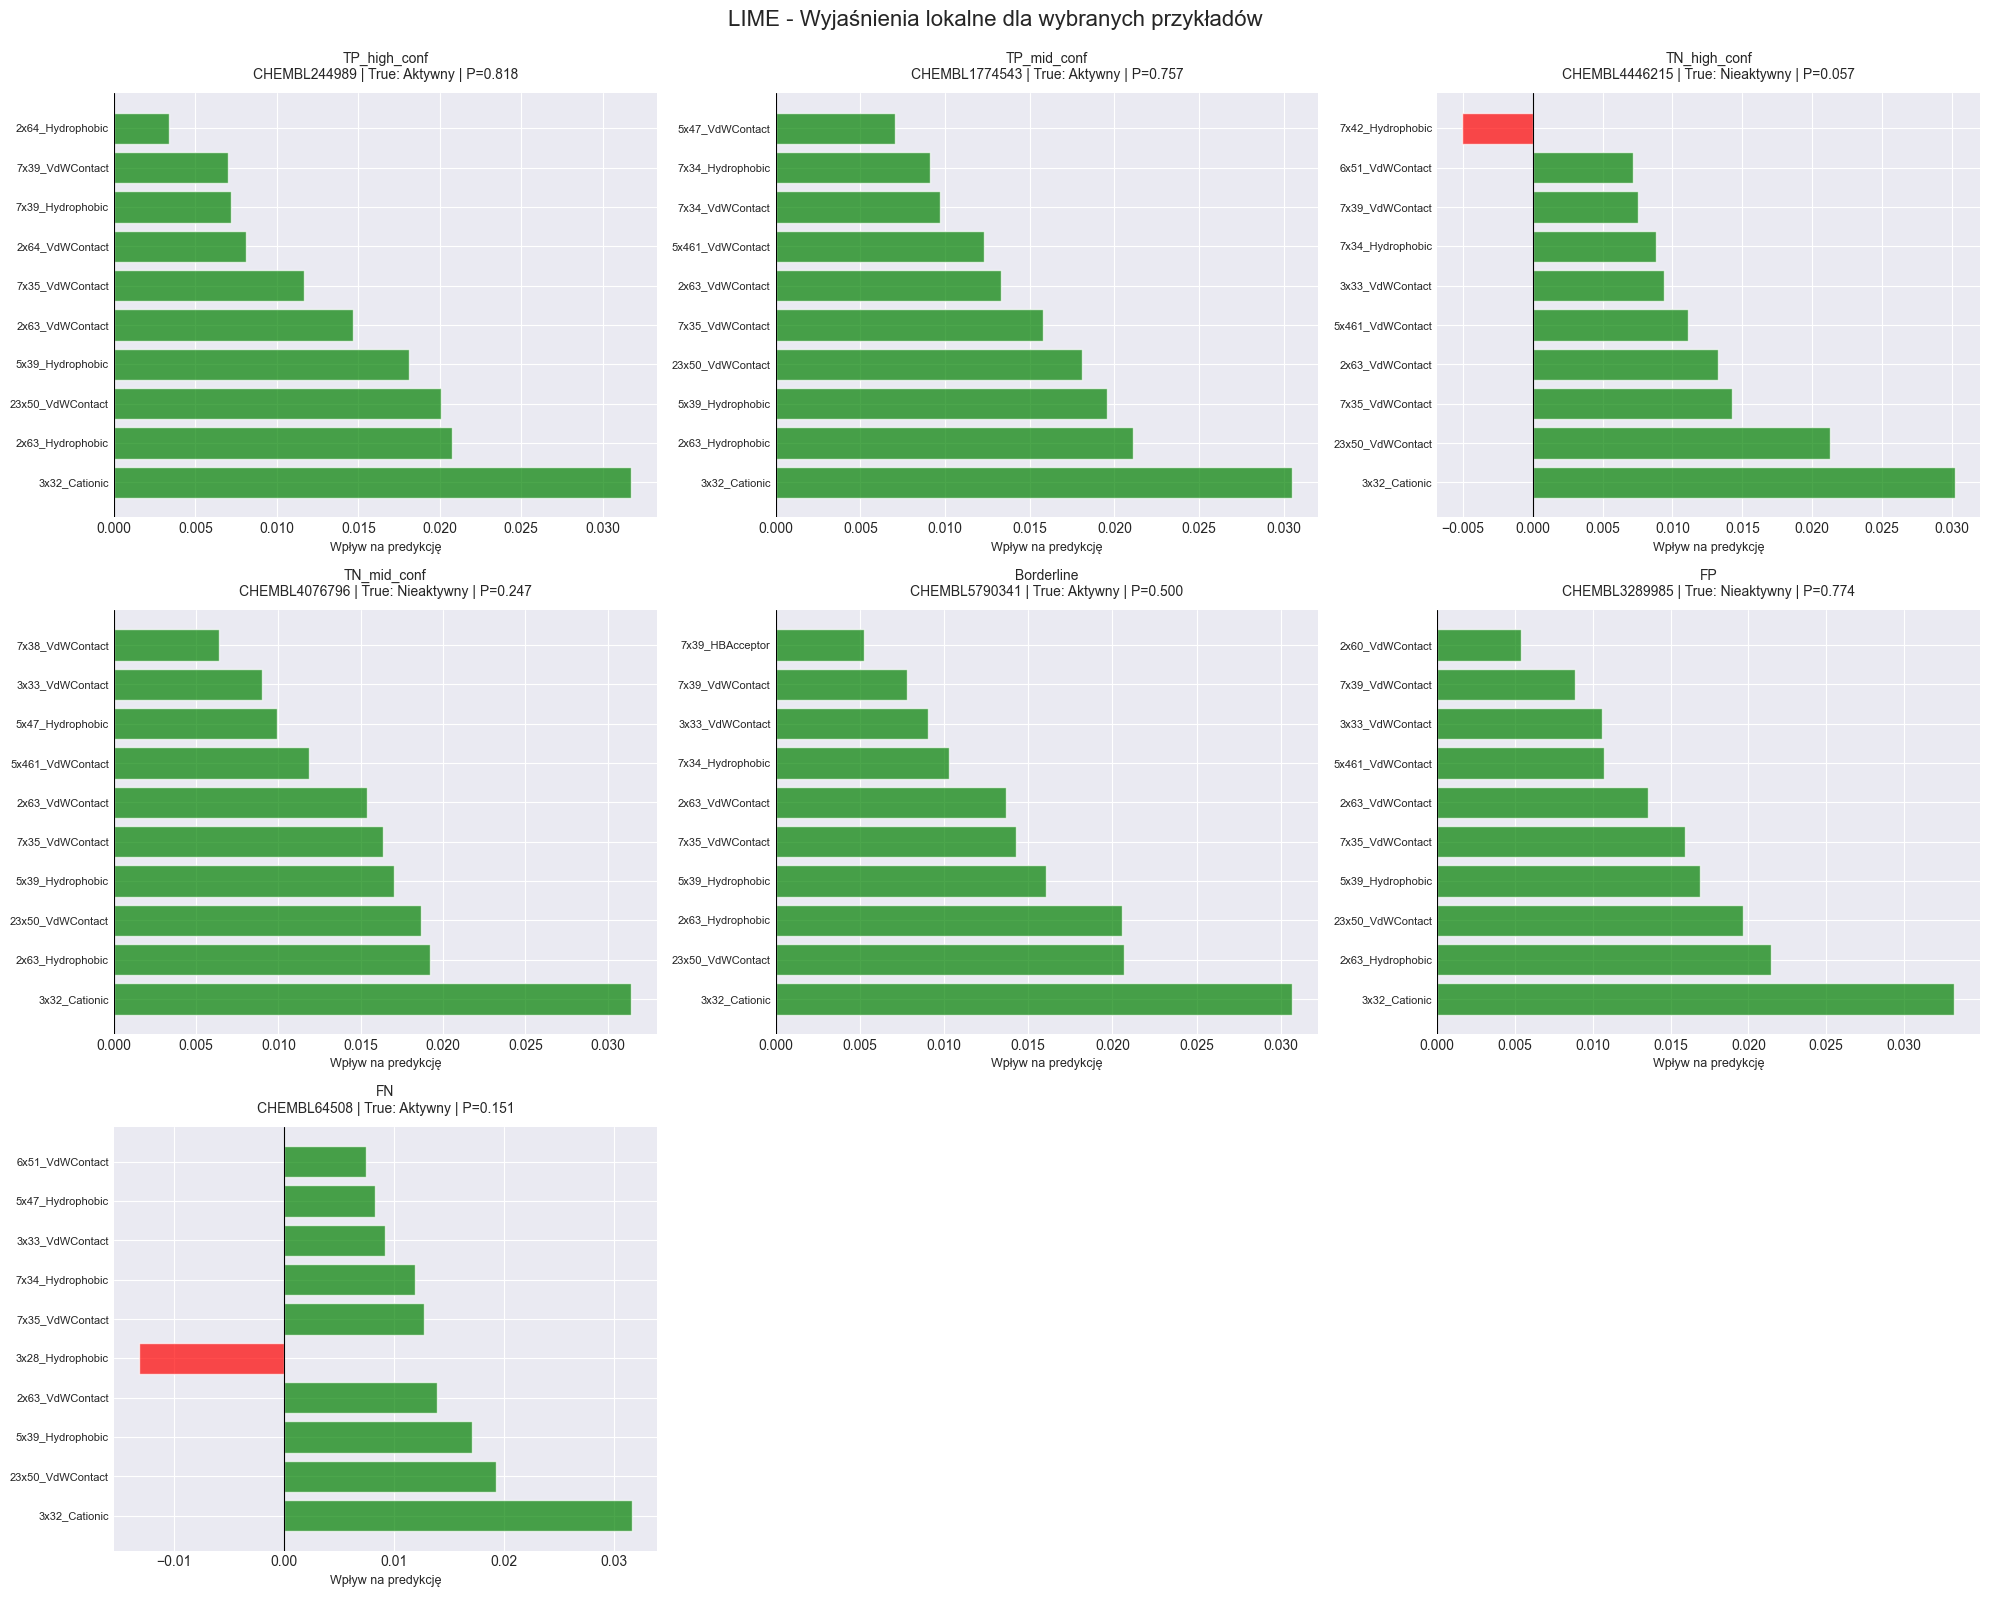


Interpretacja:
  - Zielone paski w prawo = cecha zwiększa aktywność
  - Czerwone paski w lewo = cecha zmniejsza aktywność


In [28]:
# Wizualizacja LIME - wszystkie przykłady na jednym panelu
n_examples = len(examples)
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for plot_idx, (ex_type, ex_idx) in enumerate(examples):
    # Pobierz wyniki LIME dla tego przykładu
    lime_res = lime_results[ex_type]
    exp_list = lime_res['explanation']
    mol_name = lime_res['mol_name']
    true_label = lime_res['true_label']
    pred_prob = lime_res['pred_prob']
    
    # Przygotuj dane do wykresu
    features = [e[0] for e in exp_list]
    values = [e[1] for e in exp_list]
    colors = ['green' if v > 0 else 'red' for v in values]
    
    # Wykres
    ax = axes[plot_idx]
    y_pos = np.arange(len(features))
    ax.barh(y_pos, values, color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=8)
    ax.set_xlabel('Wpływ na predykcję', fontsize=9)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    
    # Tytuł z informacjami
    true_label_str = 'Aktywny' if true_label == 1 else 'Nieaktywny'
    title = f'{ex_type}\n'
    title += f'{mol_name} | True: {true_label_str} | P={pred_prob:.3f}'
    ax.set_title(title, fontsize=10, pad=10)

# Usuń puste subploty
for i in range(n_examples, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('LIME - Wyjaśnienia lokalne dla wybranych przykładów', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print('\nInterpretacja:')
print('  - Zielone paski w prawo = cecha zwiększa aktywność')
print('  - Czerwone paski w lewo = cecha zmniejsza aktywność')

## 6. Porównanie LIME vs SHAP

**Analiza zgodności:**
- Dla każdego przykładu porównujemy top 10 cech z LIME i SHAP
- Obliczamy overlap (ile cech jest w obu top 10)
- Sprawdzamy zgodność kierunku (czy obie metody zgadzają się że cecha zwiększa/zmniejsza aktywność)

**Oczekiwania:**
- Wysoka zgodność (>70%) -> proste zależności, wysokie zaufanie
- Niska zgodność (<50%) -> skomplikowane interakcje, ostrożność w interpretacji

In [29]:
# Porównaj LIME i SHAP dla każdego przykładu
print('Porównanie LIME vs SHAP\n')
print(f'{"Przykład":<15} {"Overlap top 10":<15} {"Zgodność kierunku":<20}')
print('-' * 50)

for ex_type, ex_idx in examples:
    # LIME top features
    lime_exp = lime_results[ex_type]['explanation']
    lime_features = {feat.split('<=')[0].split('>')[0].strip(): val for feat, val in lime_exp}
    
    # SHAP top features dla tego przykładu
    shap_vals_example = shap_values_class1[ex_idx]
    shap_top_indices = np.argsort(np.abs(shap_vals_example))[-10:][::-1]
    shap_features = {feature_names[i]: shap_vals_example[i] for i in shap_top_indices}
    
    # Overlap - ile cech jest w obu top 10
    lime_feat_names = set(lime_features.keys())
    shap_feat_names = set(shap_features.keys())
    overlap = lime_feat_names.intersection(shap_feat_names)
    overlap_pct = len(overlap) / 10 * 100
    
    # Zgodność kierunku dla wspólnych cech
    if len(overlap) > 0:
        agreement = 0
        for feat in overlap:
            lime_sign = np.sign(lime_features[feat])
            shap_sign = np.sign(shap_features[feat])
            if lime_sign == shap_sign:
                agreement += 1
        agreement_pct = agreement / len(overlap) * 100
    else:
        agreement_pct = 0
    
    print(f'{ex_type:<15} {overlap_pct:>5.1f}% ({len(overlap)}/10) {agreement_pct:>8.1f}%')

print('\nInterpretacja:')
print('  - Overlap: % wspólnych cech w top 10')
print('  - Zgodność kierunku: % wspólnych cech z tym samym znakiem (+/-)')
print('  - Wysoka zgodność -> proste zależności, wysokie zaufanie')
print('  - Niska zgodność -> skomplikowane interakcje między cechami')

Porównanie LIME vs SHAP

Przykład        Overlap top 10  Zgodność kierunku   
--------------------------------------------------
TP_high_conf     80.0% (8/10)     87.5%
TP_mid_conf      70.0% (7/10)     85.7%
TN_high_conf     60.0% (6/10)     16.7%
TN_mid_conf      70.0% (7/10)     14.3%
Borderline       80.0% (8/10)     50.0%
FP               90.0% (9/10)     88.9%
FN               70.0% (7/10)     28.6%

Interpretacja:
  - Overlap: % wspólnych cech w top 10
  - Zgodność kierunku: % wspólnych cech z tym samym znakiem (+/-)
  - Wysoka zgodność -> proste zależności, wysokie zaufanie
  - Niska zgodność -> skomplikowane interakcje między cechami


## 7. Feature Selection based on SHAP

1. Obliczamy średnią absolutną wartość SHAP dla każdej cechy
2. Wybieramy top K cech (testujemy: 20, 50, 100)
3. Trenujemy model TYLKO na tych cechach
4. Porównujemy AUC: wszystkie cechy vs wybrane

In [30]:
# Feature selection based on SHAP
print('Feature Selection based on SHAP...\n')

# Mamy już obliczone: shap_importance_df (feature, mean_abs_shap)
# Testujemy różne liczby cech
feature_counts = [20, 50, 100]
results = {'all_features': {'n_features': len(feature_names), 'auc': auc}}

for n_features in feature_counts:
    print(f'\n{"="*70}')
    print(f'Testowanie z top {n_features} cechami...')
    print(f'{"="*70}\n')
    
    # Wybierz top N cech
    top_features = shap_importance_df.head(n_features)['feature'].tolist()
    
    print(f'Top {min(10, n_features)} cech:')
    for i, feat in enumerate(top_features[:10], 1):
        mean_shap = shap_importance_df[shap_importance_df['feature'] == feat]['mean_abs_shap'].values[0]
        print(f'  {i:2d}. {feat:<45} (SHAP: {mean_shap:.4f})')
    
    # Filtruj dane
    X_train_reduced = X_train[top_features]
    X_test_reduced = X_test[top_features]
    
    # Trenuj nowy model
    model_reduced = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='log2',
        random_state=42,
        n_jobs=-1
    )
    
    model_reduced.fit(X_train_reduced, y_train)
    
    # Ewaluacja
    y_prob_reduced = model_reduced.predict_proba(X_test_reduced)[:, 1]
    auc_reduced = roc_auc_score(y_test, y_prob_reduced)
    
    # Zapisz wyniki
    results[f'top_{n_features}'] = {
        'n_features': n_features,
        'auc': auc_reduced,
        'features': top_features
    }
    
    # Zmiana względem baseline
    auc_diff = auc_reduced - auc
    
    print(f'\nModel z {n_features} cechami:')
    print(f'  AUC: {auc_reduced:.3f}')
    print(f'  Zmiana: {auc_diff:+.3f} ({auc_diff/auc*100:+.1f}%)')

print(f'\n{"="*70}')
print('Podsumowanie Feature Selection')
print(f'{"="*70}\n')

print(f'{"Liczba cech":<15} {"AUC":<10} {"Zmiana vs all":<15} {"Retencja wydajności":<20}')
print('-' * 70)

baseline_auc = results['all_features']['auc']
for key in ['all_features'] + [f'top_{n}' for n in feature_counts]:
    res = results[key]
    n_feat = res['n_features']
    auc_val = res['auc']
    auc_diff = auc_val - baseline_auc
    retention = auc_val / baseline_auc * 100
    
    print(f'{n_feat:<15} {auc_val:<10.3f} {auc_diff:>+7.3f} {retention:>15.1f}%')

print('\nWnioski:')
print('  - Retencja >95% -> te cechy są wystarczające')
print('  - Im mniej cech przy zachowaniu wydajności -> prostszy model')

Feature Selection based on SHAP...


Testowanie z top 20 cechami...

Top 10 cech:
   1. 3x32_Cationic                                 (SHAP: 0.0413)
   2. 23x50_VdWContact                              (SHAP: 0.0275)
   3. 2x63_Hydrophobic                              (SHAP: 0.0184)
   4. 5x39_Hydrophobic                              (SHAP: 0.0178)
   5. 7x35_VdWContact                               (SHAP: 0.0165)
   6. 2x63_VdWContact                               (SHAP: 0.0163)
   7. 7x34_Hydrophobic                              (SHAP: 0.0159)
   8. 7x34_VdWContact                               (SHAP: 0.0144)
   9. 3x28_Hydrophobic                              (SHAP: 0.0139)
  10. 5x461_VdWContact                              (SHAP: 0.0117)

Model z 20 cechami:
  AUC: 0.676
  Zmiana: -0.046 (-6.4%)

Testowanie z top 50 cechami...

Top 10 cech:
   1. 3x32_Cationic                                 (SHAP: 0.0413)
   2. 23x50_VdWContact                              (SHAP: 0.0275)
   3. 2x6

In [32]:
# Zapisz wyniki do pliku

# Top cechy SHAP
shap_importance_df.to_csv('shap_feature_importance.csv', index=False)
print('Zapisano: shap_feature_importance.csv')

# Wyniki feature selection
fs_results_df = pd.DataFrame([
    {
        'n_features': res['n_features'],
        'auc': res['auc'],
        'auc_diff': res['auc'] - baseline_auc,
        'retention_pct': res['auc'] / baseline_auc * 100
    }
    for res in results.values()
])
fs_results_df.to_csv('feature_selection_results.csv', index=False)
print('Zapisano: feature_selection_results.csv')

print('\nWygenerowane pliki:')
print('  - shap_feature_importance.csv')
print('  - feature_selection_results.csv')
print('\nWszystkie wykresy są w notebooku powyżej')

Zapisywanie wyników...

Zapisano: shap_feature_importance.csv
Zapisano: feature_selection_results.csv

Analiza zakończona!

Wygenerowane pliki:
  - shap_feature_importance.csv
  - feature_selection_results.csv

Wszystkie wykresy są w notebooku powyżej
